In [1]:
!uv pip install scikit-learn lightgbm pandas pyarrow matplotlib

Using Python 3.14.4 environment at: /home/nik/personal/lefts/.venv
Checked 5 packages in 4ms


In [19]:
import io
import urllib.request
import zipfile

import polars as pl
from lightgbm import LGBMRegressor

from lefts import ensemble, leaf, lift
from lefts.helpers import tabular_model
import datetime as dt

import warnings

In [21]:
warnings.filterwarnings("ignore", message="X does not have valid feature names, but LGBMRegressor was fitted with feature names")

In [22]:
url = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"
with urllib.request.urlopen(url) as response:
    archive = zipfile.ZipFile(io.BytesIO(response.read()))
df = pl.read_csv(io.BytesIO(archive.read("hour.csv")))

df = df.with_columns(
    datetime = pl.col('dteday').str.to_datetime() + pl.duration(hours=pl.col('hr'))
).drop('dteday')

In [23]:
features = ["temp", "atemp", "hum", "windspeed", "hr", "weekday", "mnth"]
target = "cnt"
quantiles = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
test_period_start_dates = pl.datetime_range(
    start = dt.datetime(2011, 3, 1),
    end = dt.datetime(2012, 12, 1),
    interval='1mo',
    eager=True
).to_list()

quantile_models = []
for q in quantiles:
    # Convert LGBMRegressor into the format required by lefts
    base_model = leaf(tabular_model(
                LGBMRegressor(objective="quantile", alpha=q),
                features=features,
                target=target,
            ),
            label=f"q{q}",
                     )

    # 'Lift' each per-quantile model into a family of models, each with a different train and test period
    rolling_retrain = lift(
        base_model,
        name=f"q{q}_rolling_retrain",
        values=test_period_start_dates,

        # A row is in a given train period if it is 
        train_filter=lambda test_period_start_date: pl.col("datetime") < test_period_start_date,
        test_filter=lambda test_period_start_date: pl.col("datetime").dt.month() == test_period_start_date.month,
        aggregate_with=pl.coalesce,
    )

    quantile_models.append(rolling_retrain)

model = ensemble("quantiles", *quantile_models)

# Fits |quantiles| x |test_period_start_dates| models
model.fit(df)

# Adds |quantiles| columns, each with the unique prediction associated with that test row. 
predictions = model.predict(df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 258
[LightGBM] [Info] Number of data points in the train set: 6442, number of used features: 7
[LightGBM] [Info] Start training from score 7.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000063 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 266
[LightGBM] [Info] Number of data points in the train set: 10078, number of used features: 7
[LightGBM] [Info] Start training from score 7.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000080 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, yo

<Axes: xlabel='datetime'>

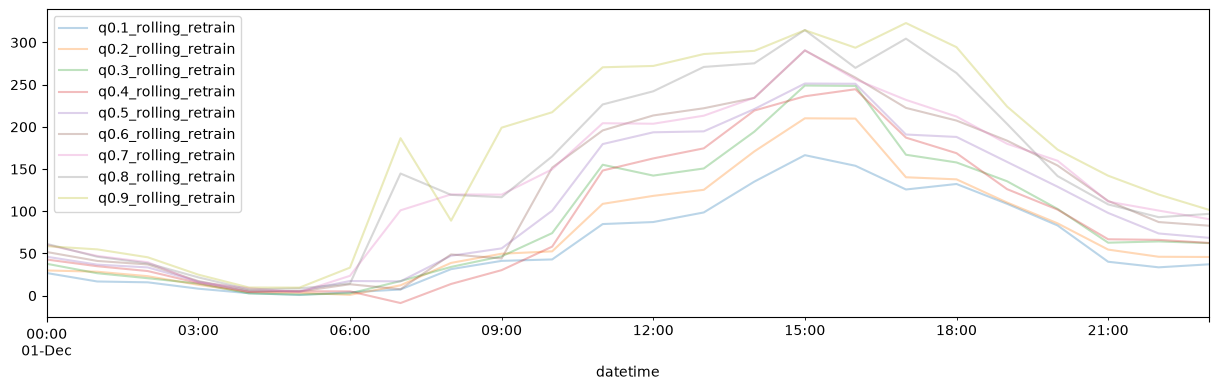

In [24]:
predictions.filter(
    pl.col('datetime').dt.date() == dt.date(2012, 12, 1)
).select('datetime', *model.collect_labels()
        ).to_pandas().set_index('datetime').plot(figsize=[15, 4], alpha=0.3)